In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
train = pd.read_csv('/kaggle/input/forecasting-mini-course-sales/train.csv')
train.head()

,id,date,country,store,product,num_sold
0,0,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Improve Your Coding,63
1,1,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Train More LLMs,66
2,2,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win Friends and Influence People,9
3,3,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win More Kaggle Competitions,59
4,4,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Write Better,49


In [4]:
test = pd.read_csv('/kaggle/input/forecasting-mini-course-sales/train.csv')
test.head()

,id,date,country,store,product,num_sold
0,0,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Improve Your Coding,63
1,1,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Train More LLMs,66
2,2,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win Friends and Influence People,9
3,3,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win More Kaggle Competitions,59
4,4,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Write Better,49


In [5]:
combined = pd.concat([train,test])
combined.head()

,id,date,country,store,product,num_sold
0,0,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Improve Your Coding,63
1,1,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Train More LLMs,66
2,2,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win Friends and Influence People,9
3,3,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win More Kaggle Competitions,59
4,4,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Write Better,49


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273900 entries, 0 to 136949
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        273900 non-null  int64 
 1   date      273900 non-null  object
 2   country   273900 non-null  object
 3   store     273900 non-null  object
 4   product   273900 non-null  object
 5   num_sold  273900 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 14.6+ MB


In [43]:
combined.dtypes

id           int64
date        object
country     object
store       object
product     object
num_sold     int64
dtype: object

In [44]:
combined.columns


Index(['id', 'date', 'country', 'store', 'product', 'num_sold'], dtype='object')

In [45]:
combined.isnull().sum()/len('combined')*100

id          0.0
date        0.0
country     0.0
store       0.0
product     0.0
num_sold    0.0
dtype: float64

In [46]:
combined.shape

(273900, 6)

<Axes: >

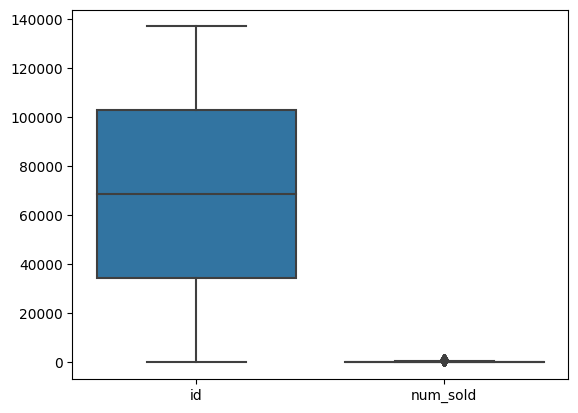

In [47]:
sns.boxplot(combined)

<Axes: >

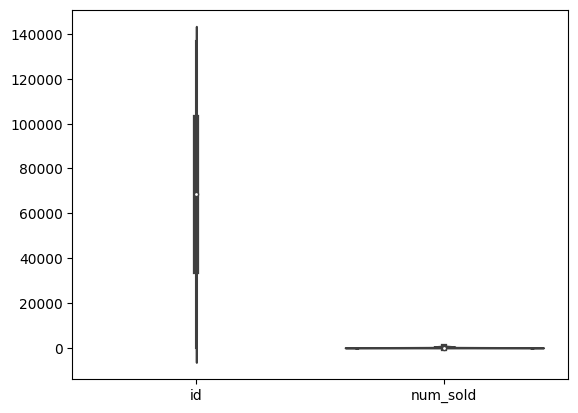

In [48]:
sns.violinplot(combined)

<Axes: >

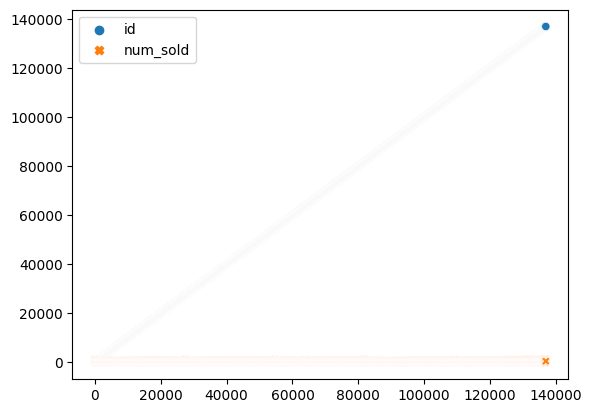

In [49]:
sns.scatterplot(combined)

<Axes: ylabel='Density'>

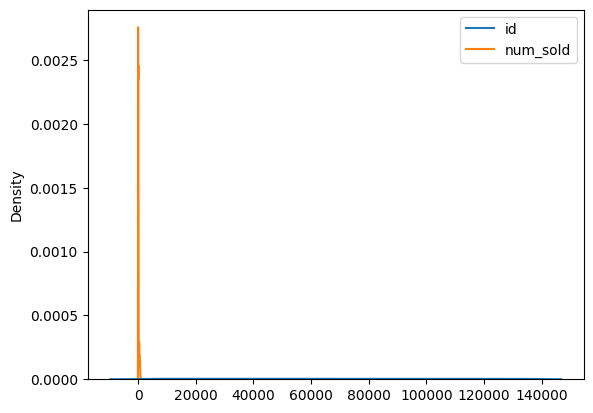

In [50]:
sns.kdeplot(combined) 

In [ ]:
sns.barplot(combined)

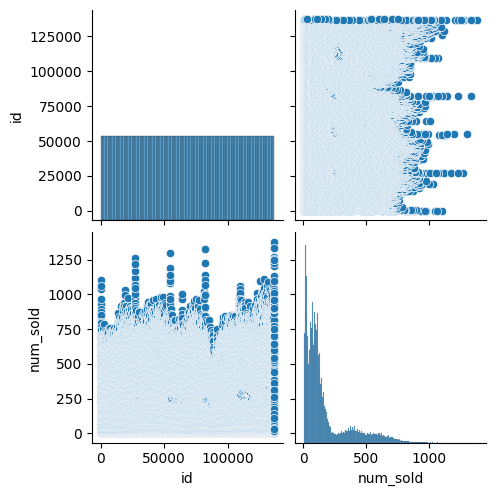

In [51]:
sns.pairplot(combined) 

In [52]:
combined.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of             id        date    country         store  \
0            0  2017-01-01  Argentina  Kaggle Learn   
1            1  2017-01-01  Argentina  Kaggle Learn   
2            2  2017-01-01  Argentina  Kaggle Learn   
3            3  2017-01-01  Argentina  Kaggle Learn   
4            4  2017-01-01  Argentina  Kaggle Learn   
...        ...         ...        ...           ...   
136945  136945  2021-12-31      Spain     Kagglazon   
136946  136946  2021-12-31      Spain     Kagglazon   
136947  136947  2021-12-31      Spain     Kagglazon   
136948  136948  2021-12-31      Spain     Kagglazon   
136949  136949  2021-12-31      Spain     Kagglazon   

                                               product  num_sold  
0                    Using LLMs to Improve Your Coding        63  
1                        Using LLMs to Train More LLMs        66  
2       Using LLMs to Win Friends and Influence People         9  
3       

In [53]:
combined.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of             id        date    country         store  \
0            0  2017-01-01  Argentina  Kaggle Learn   
1            1  2017-01-01  Argentina  Kaggle Learn   
2            2  2017-01-01  Argentina  Kaggle Learn   
3            3  2017-01-01  Argentina  Kaggle Learn   
4            4  2017-01-01  Argentina  Kaggle Learn   
...        ...         ...        ...           ...   
136945  136945  2021-12-31      Spain     Kagglazon   
136946  136946  2021-12-31      Spain     Kagglazon   
136947  136947  2021-12-31      Spain     Kagglazon   
136948  136948  2021-12-31      Spain     Kagglazon   
136949  136949  2021-12-31      Spain     Kagglazon   

                                               product  num_sold  
0                    Using LLMs to Improve Your Coding        63  
1                        Using LLMs to Train More LLMs        66  
2       Using LLMs to Win Friends and Influence People         9  
3       

In [7]:
cat_cols = combined.select_dtypes(include='object')

In [8]:
for i in cat_cols:
    print(i)
    combined[i].value_counts()
    print(''*50)

date

country

store

product



In [9]:
num_cols = combined.select_dtypes(include='number')

In [10]:
for i in num_cols:
    print(i)
    combined[i].value_counts()
    print(''*50)

id

num_sold



<Axes: ylabel='count'>

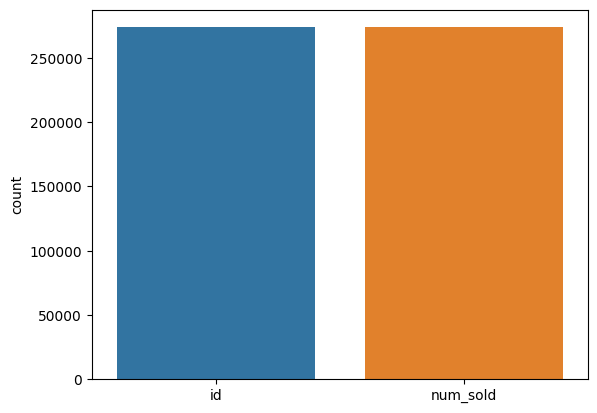

In [58]:
sns.countplot(combined)

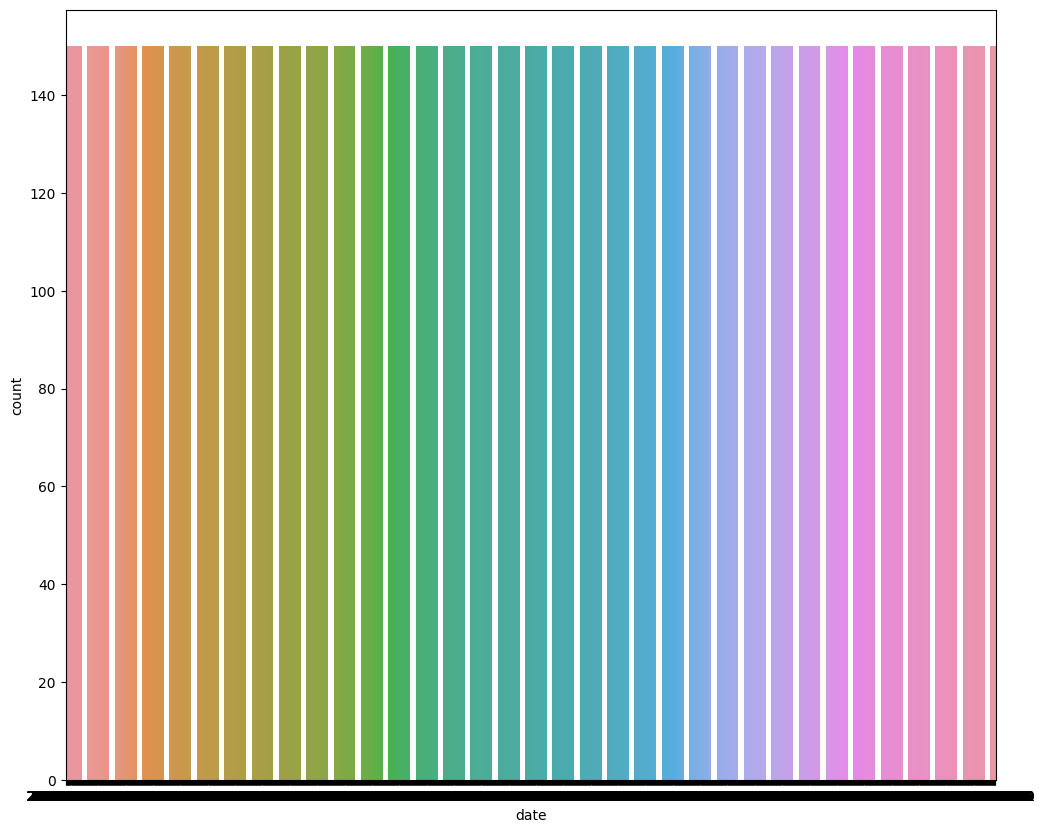

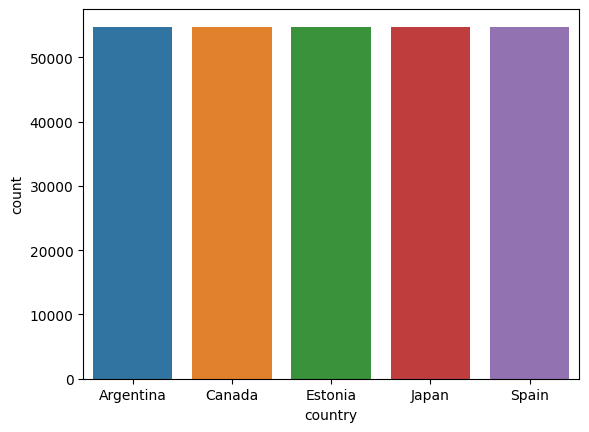

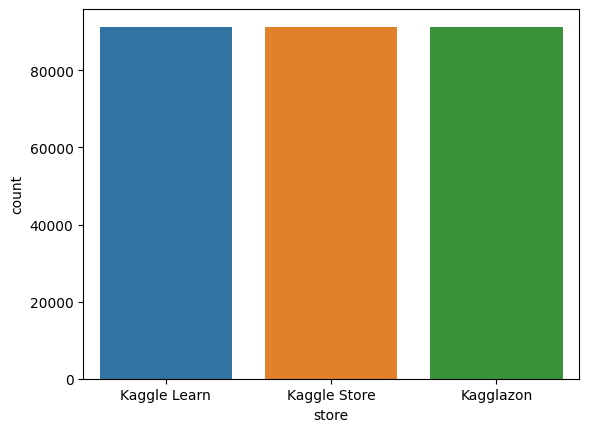

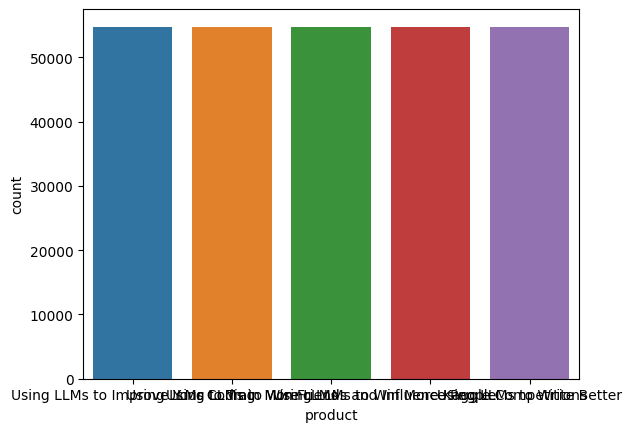

In [59]:
plt.figure(figsize=(12,10))
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

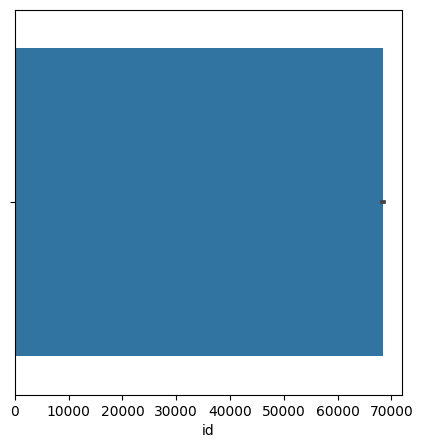

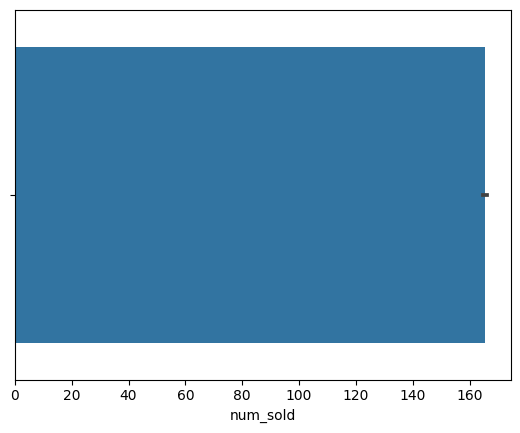

In [60]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.barplot(data=combined,x=i)
    print('\n')
    plt.show() 

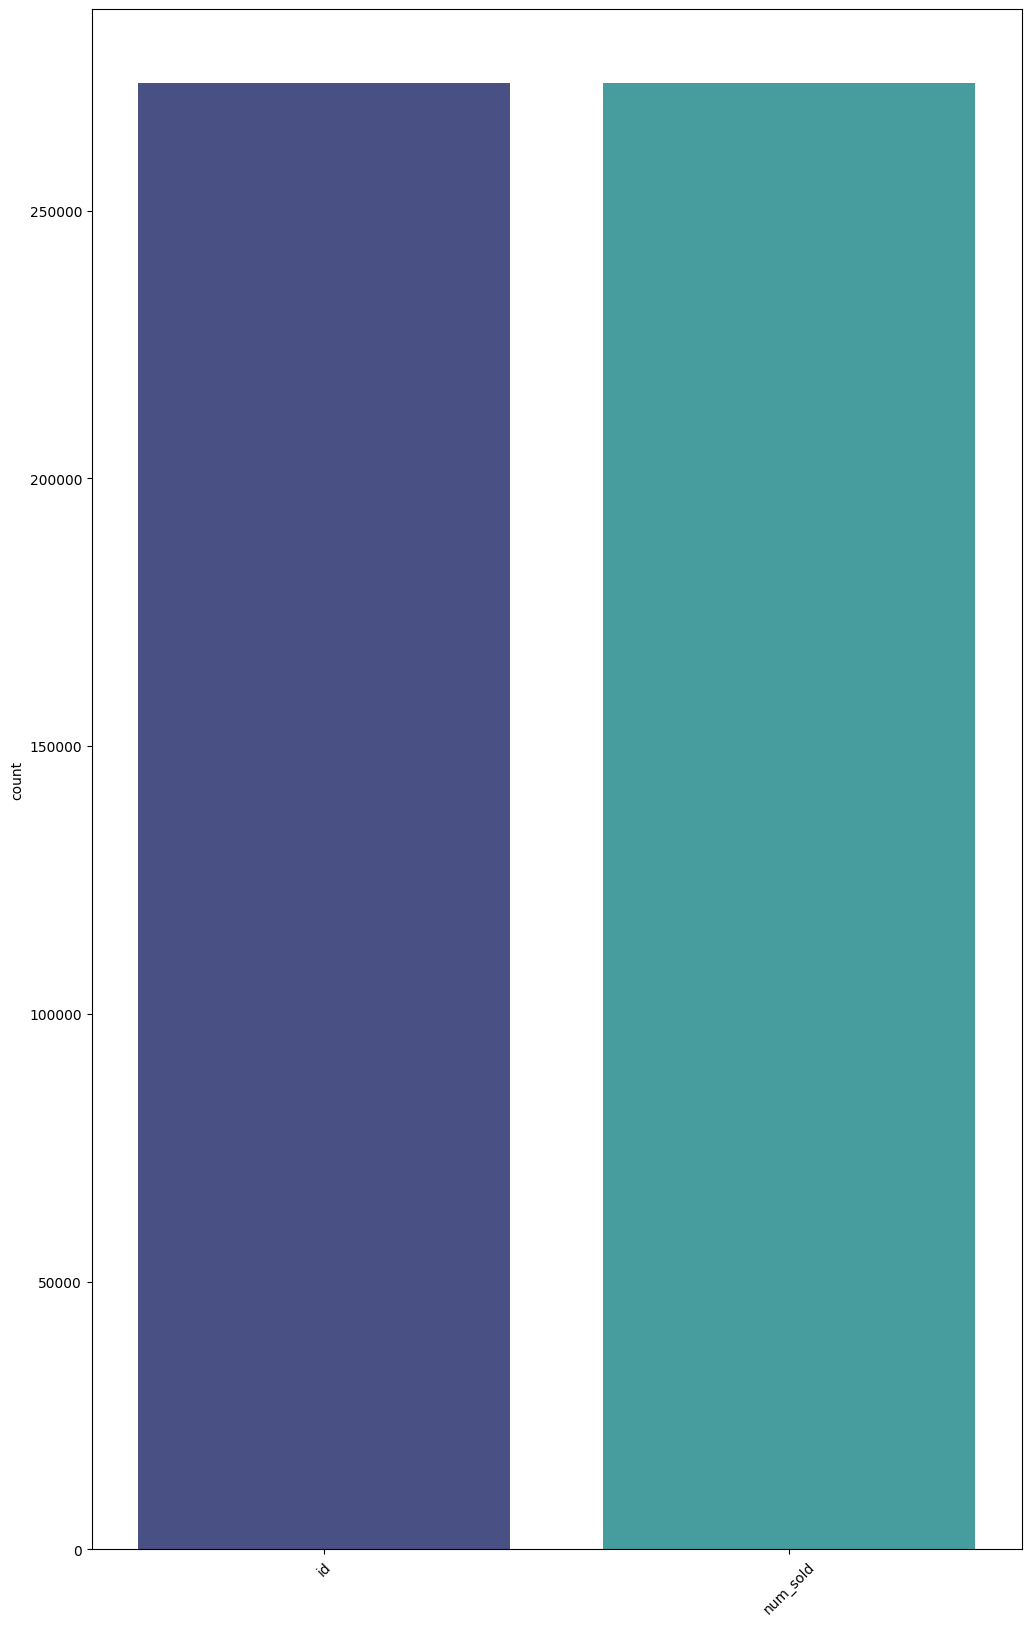

In [61]:
plt.figure(figsize=(12,20))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

(array([0, 1]), [Text(0, 0, 'id'), Text(1, 0, 'num_sold')])

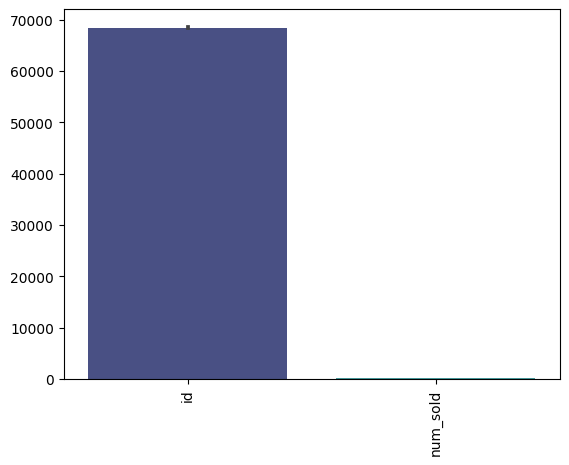

In [62]:
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=90)

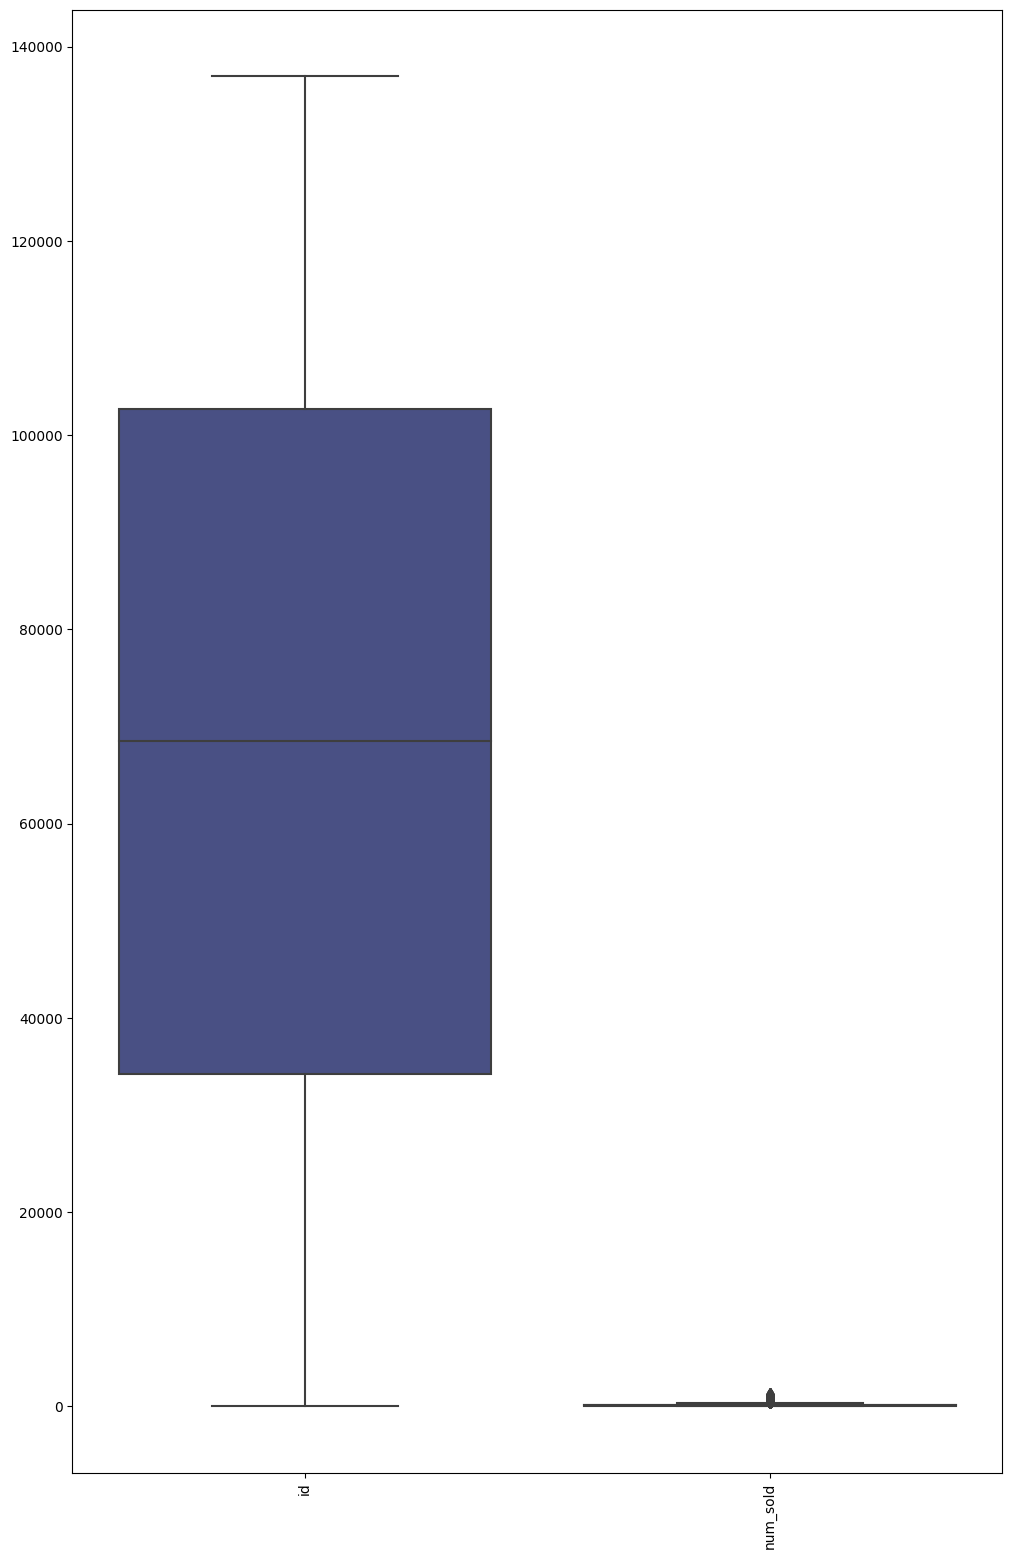

In [63]:
plt.figure(figsize=(12,19))
sns.boxplot(data=combined,palette='mako');
plt.xticks(rotation=90);

In [64]:
combined['id'].value_counts()

id
0         2
91295     2
91309     2
91308     2
91307     2
         ..
45644     2
45643     2
45642     2
45641     2
136949    2
Name: count, Length: 136950, dtype: int64

In [65]:
combined.head()

,id,date,country,store,product,num_sold
0,0,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Improve Your Coding,63
1,1,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Train More LLMs,66
2,2,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win Friends and Influence People,9
3,3,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Win More Kaggle Competitions,59
4,4,2017-01-01,Argentina,Kaggle Learn,Using LLMs to Write Better,49


In [11]:
x = combined [['id']]

In [12]:
y = combined[['id']]

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3)

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(x_train,y_train)

LinearRegression()

In [18]:
y_pred=lr.predict(x_test)

In [19]:
y_test.head(), y_pred[0:5]

(            id
 121189  121189
 133140  133140
 47473    47473
 119541  119541
 45053    45053,
 array([[121189.],
        [133140.],
        [ 47473.],
        [119541.],
        [ 45053.]]))

In [20]:
from sklearn.metrics import mean_squared_error

In [21]:
mean_squared_error(y_test,y_pred)

4.837333613478074e-23

In [ ]:
from sklearn.tree import DecisionTreeClassifier ,plot_tree
import matplotlib.pyplot as plt


decision_tree_classification = DecisionTreeClassifier(criterion='entropy', random_state=10)
decision_tree = decision_tree_classification.fit(x_train,y_train)

plt.figure(figsize=(12,9))
plot_tree(decision_tree, max_depth=3, feature_names = x_train.columns, rounded=True)
plt.show() 

In [ ]:
y_pred_test = decision_tree.predict(x_test)
y_pred_train = decision_tree(x_train)
print(decision_tree)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_train,y_pred_train))

In [ ]:
print(len(y_train),len(y_pred_train))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))